# 04. Диагностика потерянного сигнала `Q_B1` / `Q_B2` — V2

## Главный исследовательский вопрос

**Содержат ли закрытые индексы `Q_B1_norm` и `Q_B2_norm` дополнительный сигнал именно в общей слепой зоне baseline без этих индексов, если сравнивать их честно при одинаковой доле компаний, попадающих в диагностическую risk-zone?**

## Почему существует V2

V1 корректно показал самостоятельный сигнал закрытых индексов и их комплементарность baseline, но сравнение `blind spot rescue` через пороги percentile-rank оказалось методологически некорректным.

Причина: `Q_B1_norm` и `Q_B2_norm` имеют очень крупные группы одинаковых значений. При `rank(method="average", pct=True)` порог вроде `>= 0.90` **не гарантирует одинаковые 10% компаний** для разных индексов. Поэтому V1 сравнивал rescue при разной фактической ёмкости risk-zone.

V2 сохраняет V1 как историю и исправляет только этот вопрос.

### Контролируемый эксперимент

Не меняются:

- dataset и SHA-256;
- working/final split;
- OOF checkpoint Stage 3;
- определение общей слепой зоны Stage 3;
- final test остаётся закрытым;
- `Q_B1_norm` и `Q_B2_norm` остаются только diagnostic reference и не входят в production feature set.

Меняется только способ сравнения `rescue`:

- фиксируем одинаковую ёмкость risk-zone: 10%, 20%, 30% working sample;
- при попадании границы внутрь группы одинаковых score считаем ожидаемый rescue при случайном выборе внутри tie-группы;
- дополнительно показываем нижнюю и верхнюю границы rescue, возможные внутри boundary tie.

### Что этот эксперимент не доказывает

- закрытые индексы не становятся разрешёнными признаками;
- association не доказывает causality;
- oracle-mix не является production-моделью;
- random split не доказывает temporal stability.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split


def найти_корень_проекта(начало: Path | None = None) -> Path:
    """Находит корень проекта по pyproject.toml."""
    текущая = (начало or Path.cwd()).resolve()
    for кандидат in [текущая, *текущая.parents]:
        if (кандидат / "pyproject.toml").exists():
            return кандидат
    raise FileNotFoundError("Не найден корень проекта с pyproject.toml.")


def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    """Вычисляет SHA-256 файла блоками."""
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def хэш_массива(значения: np.ndarray) -> str:
    """Вычисляет SHA-256 массива индексов."""
    массив = np.asarray(значения, dtype=np.int64)
    return hashlib.sha256(массив.tobytes()).hexdigest()


КОРЕНЬ_ПРОЕКТА = найти_корень_проекта()
ПУТЬ_К_ДАТАСЕТУ = КОРЕНЬ_ПРОЕКТА / "data" / "raw" / "Data_final.xlsb"
ПАПКА_GENERATED = КОРЕНЬ_ПРОЕКТА / "reports" / "generated"
ПАПКА_SUMMARY = КОРЕНЬ_ПРОЕКТА / "reports" / "summary"
ПУТЬ_OOF = ПАПКА_GENERATED / "stage3_oof_predictions_V1.npz"

ПАПКА_GENERATED.mkdir(parents=True, exist_ok=True)
ПАПКА_SUMMARY.mkdir(parents=True, exist_ok=True)

ОЖИДАЕМЫЙ_SHA_DATASET = "fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930"
ОЖИДАЕМЫЙ_SHA_РАБОТА = "80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d23d9fca00091aadb45"
ОЖИДАЕМЫЙ_SHA_TEST = "35ec963fe82918841f4a8acb012e8fc878aed66d2c5296ea6cb105177cafbb37"
ОЖИДАЕМЫЙ_SHA_OOF = "faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300f9a8860112ff4473ac"

ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ = "DefMark"
ЗАКРЫТЫЕ_ИНДЕКСЫ = ["Q_B1_norm", "Q_B2_norm"]

ДОЛЯ_ФИНАЛЬНОГО_TEST = 0.20
СЛУЧАЙНОЕ_ЗЕРНО = 42

ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА = 0.50
ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА = 0.90
МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ = 0.10

ЁМКОСТИ = [0.10, 0.20, 0.30]

ОЖИДАЕМЫЙ_GINI_V2 = {
    "CatBoost": 0.803779690692136,
    "XGBoost": 0.8039898778800276,
    "LightGBM": 0.8033629488861926,
}

print("Корень проекта:", КОРЕНЬ_ПРОЕКТА)
print("Python:", platform.python_version())
print("Dataset:", ПУТЬ_К_ДАТАСЕТУ)
print("OOF checkpoint:", ПУТЬ_OOF)

Корень проекта: D:\Projects\komus-credit-risk
Python: 3.12.2
Dataset: D:\Projects\komus-credit-risk\data\raw\Data_final.xlsb
OOF checkpoint: D:\Projects\komus-credit-risk\reports\generated\stage3_oof_predictions_V1.npz


# 1. Gate идентичности dataset, split и OOF

## Исследовательский вопрос

Использует ли V2 точно тот же dataset, working/final split и Stage 3 OOF checkpoint?

При любом несовпадении эксперимент останавливается.


In [2]:
if not ПУТЬ_К_ДАТАСЕТУ.exists():
    raise FileNotFoundError(f"Dataset не найден: {ПУТЬ_К_ДАТАСЕТУ}")

if not ПУТЬ_OOF.exists():
    raise FileNotFoundError(
        "Не найден Stage 3 OOF checkpoint: "
        f"{ПУТЬ_OOF}"
    )

sha_dataset = вычислить_sha256(ПУТЬ_К_ДАТАСЕТУ)
sha_oof = вычислить_sha256(ПУТЬ_OOF)

if sha_dataset.lower() != ОЖИДАЕМЫЙ_SHA_DATASET.lower():
    raise RuntimeError(
        "SHA-256 dataset не совпал с зафиксированной версией."
    )

if sha_oof.lower() != ОЖИДАЕМЫЙ_SHA_OOF.lower():
    raise RuntimeError(
        "SHA-256 OOF checkpoint не совпал со Stage 3 V1."
    )

данные = pd.read_excel(
    ПУТЬ_К_ДАТАСЕТУ,
    engine="pyxlsb",
    sheet_name="Data_final",
    usecols=[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ЗАКРЫТЫЕ_ИНДЕКСЫ],
).reset_index(drop=True)

for столбец in [ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ЗАКРЫТЫЕ_ИНДЕКСЫ]:
    данные[столбец] = pd.to_numeric(данные[столбец], errors="raise")

if данные[[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ЗАКРЫТЫЕ_ИНДЕКСЫ]].isna().any().any():
    raise RuntimeError("В анализируемых столбцах обнаружены пропуски.")

индексы = np.arange(len(данные))

индексы_работа_контроль, индексы_test_контроль = train_test_split(
    индексы,
    test_size=ДОЛЯ_ФИНАЛЬНОГО_TEST,
    stratify=данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ],
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

if хэш_массива(индексы_работа_контроль) != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("Working split не совпал с принятым протоколом.")

if хэш_массива(индексы_test_контроль) != ОЖИДАЕМЫЙ_SHA_TEST:
    raise RuntimeError("Final test split не совпал с принятым протоколом.")

with np.load(ПУТЬ_OOF) as checkpoint:
    working_indices = np.asarray(checkpoint["working_indices"], dtype=np.int64)
    target = np.asarray(checkpoint["target"], dtype=np.int8)
    oof_catboost = np.asarray(checkpoint["oof_catboost"], dtype=np.float64)
    oof_xgboost = np.asarray(checkpoint["oof_xgboost"], dtype=np.float64)
    oof_lightgbm = np.asarray(checkpoint["oof_lightgbm"], dtype=np.float64)
    consensus_rank = np.asarray(checkpoint["consensus_rank"], dtype=np.float64)
    rank_spread = np.asarray(checkpoint["rank_spread"], dtype=np.float64)

if хэш_массива(working_indices) != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("working_indices в OOF checkpoint имеют неожиданный SHA.")

if not np.array_equal(working_indices, индексы_работа_контроль):
    raise RuntimeError("Порядок working_indices не совпал с воспроизведённым split.")

target_dataset = (
    данные.iloc[working_indices][ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]
    .to_numpy(dtype=np.int8)
)

if not np.array_equal(target, target_dataset):
    raise RuntimeError("Target checkpoint не совпал с dataset.")

ПАСПОРТ = pd.DataFrame([
    ("SHA dataset", sha_dataset),
    ("SHA OOF checkpoint", sha_oof),
    ("Working rows", len(working_indices)),
    ("Final test rows", len(индексы_test_контроль)),
], columns=["Проверка", "Значение"])

display(ПАСПОРТ)
print("Final test зафиксирован, но не используется.")

,Проверка,Значение
0,SHA dataset,fc742be66d238c529daba52ccc755f774f836b7d052ed0...
1,SHA OOF checkpoint,faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300...
2,Working rows,289614
3,Final test rows,72404


Final test зафиксирован, но не используется.


# 2. Gate воспроизводимости OOF и Stage 3 blind spot

## Исследовательский вопрос

Совпадают ли OOF-метрики и диагностические группы с уже принятыми Stage 1/3?


In [3]:
OOF = {
    "CatBoost": oof_catboost,
    "XGBoost": oof_xgboost,
    "LightGBM": oof_lightgbm,
}

строки_качества = []

for название, вероятности in OOF.items():
    roc_auc = float(roc_auc_score(target, вероятности))
    gini = float(2 * roc_auc - 1)
    pr_auc = float(average_precision_score(target, вероятности))
    отклонение = float(gini - ОЖИДАЕМЫЙ_GINI_V2[название])

    if abs(отклонение) > 1e-6:
        raise RuntimeError(
            f"{название}: OOF Gini отличается от Stage 1 V2 "
            f"на {отклонение:+.8f}."
        )

    строки_качества.append({
        "Модель": название,
        "Gini OOF": gini,
        "PR-AUC OOF": pr_auc,
        "Отклонение Gini": отклонение,
    })

ТАБЛИЦА_КАЧЕСТВА = pd.DataFrame(строки_качества)
display(ТАБЛИЦА_КАЧЕСТВА.round(6))

маска_дефолт = target == 1
маска_недефолт = ~маска_дефолт

маска_глубокий_пропуск = (
    маска_дефолт
    & (consensus_rank <= ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА)
)

маска_хороший_дефолт = (
    маска_дефолт
    & (consensus_rank >= ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА)
)

маска_общая_слепая_зона = (
    маска_глубокий_пропуск
    & (rank_spread <= МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ)
)

ожидаемые_группы = {
    "Всего дефолтов": 28015,
    "Глубоко пропущенные дефолты": 1278,
    "Общая слепая зона": 805,
    "Хорошо ранжированные дефолты": 16026,
}

фактические_группы = {
    "Всего дефолтов": int(маска_дефолт.sum()),
    "Глубоко пропущенные дефолты": int(маска_глубокий_пропуск.sum()),
    "Общая слепая зона": int(маска_общая_слепая_зона.sum()),
    "Хорошо ранжированные дефолты": int(маска_хороший_дефолт.sum()),
}

if фактические_группы != ожидаемые_группы:
    raise RuntimeError(
        "Диагностические группы Stage 3 не воспроизвелись."
    )

display(
    pd.DataFrame(
        [{"Группа": k, "Число": v} for k, v in фактические_группы.items()]
    )
)

,Модель,Gini OOF,PR-AUC OOF,Отклонение Gini
0,CatBoost,0.803780,0.600961,0.0
1,XGBoost,0.803990,0.599273,0.0
2,LightGBM,0.803363,0.597750,0.0


,Группа,Число
0,Всего дефолтов,28015
1,Глубоко пропущенные дефолты,1278
2,Общая слепая зона,805
3,Хорошо ранжированные дефолты,16026


# 3. Почему V1 нельзя использовать для сравнения rescue

## Исследовательский вопрос

Насколько дискретны `Q_B1_norm` и `Q_B2_norm` и создают ли ties разную фактическую ёмкость percentile-зон?

Это ключевая методологическая проверка V2.


In [4]:
закрытые_work = (
    данные.iloc[working_indices][ЗАКРЫТЫЕ_ИНДЕКСЫ]
    .reset_index(drop=True)
    .astype("float64")
)

строки_дискретности = []

for признак in ЗАКРЫТЫЕ_ИНДЕКСЫ:
    частоты = закрытые_work[признак].value_counts(normalize=True)
    строки_дискретности.append({
        "Индекс": признак,
        "Уникальных значений": int(закрытые_work[признак].nunique()),
        "Доля крупнейшей tie-группы, %": float(частоты.iloc[0] * 100),
        "Доля второй tie-группы, %": float(частоты.iloc[1] * 100),
    })

ТАБЛИЦА_ДИСКРЕТНОСТИ = pd.DataFrame(строки_дискретности)
display(ТАБЛИЦА_ДИСКРЕТНОСТИ.round(2))

for признак in ЗАКРЫТЫЕ_ИНДЕКСЫ:
    print(f"\n{признак}:")
    display(
        (
            закрытые_work[признак]
            .value_counts(normalize=True)
            .rename_axis("Значение")
            .reset_index(name="Доля")
            .assign(**{"Доля, %": lambda x: x["Доля"] * 100})
            .drop(columns="Доля")
            .round(2)
        )
    )

print(
    "\nВывод: percentile-threshold без tie correction "
    "не обеспечивает одинаковую ёмкость risk-zone."
)

,Индекс,Уникальных значений,"Доля крупнейшей tie-группы, %","Доля второй tie-группы, %"
0,Q_B1_norm,6,45.97,17.93
1,Q_B2_norm,6,67.75,15.74



Q_B1_norm:


,Значение,"Доля, %"
0,34.63,45.97
1,7.28,17.93
2,-43.67,15.85
3,-7.35,8.55
4,-13.06,6.96
5,-185.15,4.73



Q_B2_norm:


,Значение,"Доля, %"
0,21.22,67.75
1,-9.15,15.74
2,-15.36,6.69
3,-210.22,4.72
4,-46.69,3.28
5,-26.46,1.83



Вывод: percentile-threshold без tie correction не обеспечивает одинаковую ёмкость risk-zone.


# 4. Самостоятельный диагностический сигнал закрытых индексов

## Исследовательский вопрос

Насколько каждый закрытый индекс сам по себе связан с `DefMark` на working sample?

В V2 ориентация фиксирована заранее по результату V1:

- меньше `Q_B1_norm` → выше диагностический риск;
- меньше `Q_B2_norm` → выше диагностический риск.

Знак больше не выбирается по текущему target.


In [5]:
РИСК_СКОРЫ = {
    "Q_B1_norm": -закрытые_work["Q_B1_norm"].to_numpy(dtype=np.float64),
    "Q_B2_norm": -закрытые_work["Q_B2_norm"].to_numpy(dtype=np.float64),
}

РИСК_РАНГИ = {
    название: (
        pd.Series(скор)
        .rank(method="average", pct=True)
        .to_numpy(dtype=np.float64)
    )
    for название, скор in РИСК_СКОРЫ.items()
}

ЗАКРЫТЫЙ_CONSENSUS = np.mean(
    np.column_stack([
        РИСК_РАНГИ["Q_B1_norm"],
        РИСК_РАНГИ["Q_B2_norm"],
    ]),
    axis=1,
)

строки_индексов = []

for название, скор in {
    **РИСК_СКОРЫ,
    "Q_B1/Q_B2 mean-rank": ЗАКРЫТЫЙ_CONSENSUS,
}.items():
    roc_auc = float(roc_auc_score(target, скор))

    if roc_auc < 0.5:
        raise RuntimeError(
            f"{название}: фиксированная ориентация дала ROC-AUC < 0.5."
        )

    строки_индексов.append({
        "Индекс": название,
        "ROC-AUC": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": float(average_precision_score(target, скор)),
    })

ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА = pd.DataFrame(строки_индексов)
display(ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА.round(4))

pearson_raw = float(
    закрытые_work["Q_B1_norm"].corr(
        закрытые_work["Q_B2_norm"],
        method="pearson",
    )
)
spearman_raw = float(
    закрытые_work["Q_B1_norm"].corr(
        закрытые_work["Q_B2_norm"],
        method="spearman",
    )
)

print(f"Pearson Q_B1 ↔ Q_B2:  {pearson_raw:.3f}")
print(f"Spearman Q_B1 ↔ Q_B2: {spearman_raw:.3f}")

,Индекс,ROC-AUC,Gini,PR-AUC
0,Q_B1_norm,0.9022,0.8044,0.6415
1,Q_B2_norm,0.8384,0.6768,0.6320
2,Q_B1/Q_B2 mean-rank,0.9090,0.8181,0.7021


Pearson Q_B1 ↔ Q_B2:  0.827
Spearman Q_B1 ↔ Q_B2: 0.405


# 5. Честный fixed-capacity blind spot rescue

## Исследовательский вопрос

Какую долю из 805 общей слепой зоны можно ожидать в risk-zone **одинакового размера** для `Q_B1` и `Q_B2`?

### Tie-aware правило

Для заданной ёмкости, например 20%:

1. целиком включаем score-группы с самым высоким риском;
2. если граница попадает внутрь tie-группы, включаем только требуемую долю этой группы;
3. поскольку внутри tie-группы score не различает строки, основной результат — **ожидаемый rescue при случайном выборе внутри tie**;
4. дополнительно показываем теоретические min/max границы rescue внутри boundary tie.

Так мы сравниваем оба индекса при одной и той же диагностической ёмкости.


,Индекс,"Ёмкость, %",Выбрано строк,"Expected rescue, %","Min rescue, %","Max rescue, %",Boundary score,"Доля boundary tie, %"
0,Q_B1_norm,10.0,28961,39.37,35.16,47.83,43.67,33.24
1,Q_B1_norm,20.0,57923,47.36,35.16,47.83,43.67,96.34
2,Q_B1_norm,30.0,86884,53.75,52.17,57.64,7.35,28.75
3,Q_B2_norm,10.0,28961,43.49,43.35,48.57,15.36,2.61
4,Q_B2_norm,20.0,57923,51.38,48.57,61.24,9.15,22.17
5,Q_B2_norm,30.0,86884,59.43,48.57,61.24,9.15,85.70


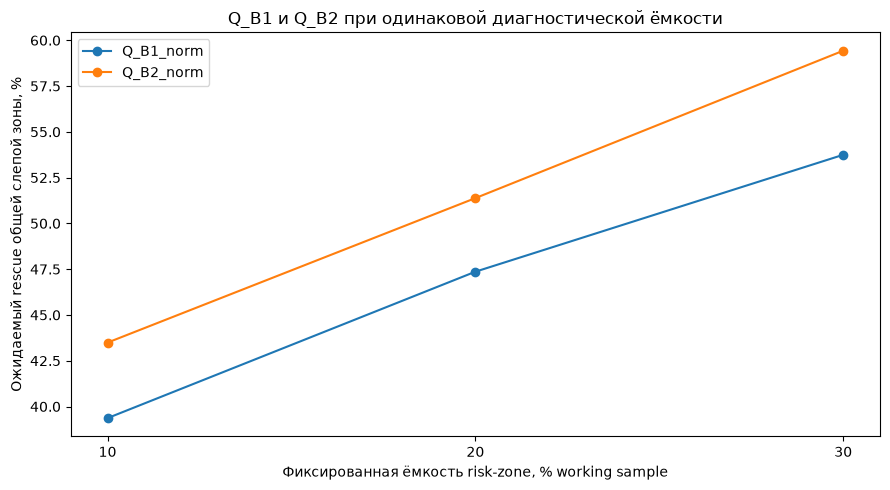

In [6]:
def tie_aware_rescue(
    score: np.ndarray,
    positive_mask: np.ndarray,
    capacity: float,
) -> dict[str, float | int]:
    """Считает expected/min/max capture positives при фиксированной ёмкости."""
    score = np.asarray(score, dtype=np.float64)
    positive_mask = np.asarray(positive_mask, dtype=bool)

    n = len(score)
    k = int(round(capacity * n))
    total_positive = int(positive_mask.sum())

    таблица = pd.DataFrame({
        "score": score,
        "positive": positive_mask.astype(int),
    })

    группы = (
        таблица
        .groupby("score", as_index=False)
        .agg(
            rows=("positive", "size"),
            positives=("positive", "sum"),
        )
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    remaining = k
    expected_positive = 0.0
    min_positive = 0.0
    max_positive = 0.0
    boundary_score = np.nan
    boundary_fraction = 0.0

    for row in группы.itertuples(index=False):
        group_rows = int(row.rows)
        group_positive = int(row.positives)
        group_negative = group_rows - group_positive

        if remaining <= 0:
            break

        if remaining >= group_rows:
            expected_positive += group_positive
            min_positive += group_positive
            max_positive += group_positive
            remaining -= group_rows
            continue

        boundary_score = float(row.score)
        boundary_fraction = remaining / group_rows

        expected_positive += boundary_fraction * group_positive

        min_additional = max(0, remaining - group_negative)
        max_additional = min(remaining, group_positive)

        min_positive += min_additional
        max_positive += max_additional
        remaining = 0

    if remaining != 0:
        raise RuntimeError("Не удалось заполнить фиксированную ёмкость.")

    return {
        "capacity": float(capacity),
        "selected_rows": int(k),
        "total_rows": int(n),
        "actual_capacity": float(k / n),
        "total_positive": total_positive,
        "expected_positive": float(expected_positive),
        "min_positive": float(min_positive),
        "max_positive": float(max_positive),
        "expected_recall": float(expected_positive / total_positive),
        "min_recall": float(min_positive / total_positive),
        "max_recall": float(max_positive / total_positive),
        "boundary_score": boundary_score,
        "boundary_fraction": float(boundary_fraction),
    }


строки_rescue = []

for индекс, score in РИСК_СКОРЫ.items():
    for capacity in ЁМКОСТИ:
        статистика = tie_aware_rescue(
            score=score,
            positive_mask=маска_общая_слепая_зона,
            capacity=capacity,
        )

        строки_rescue.append({
            "Индекс": индекс,
            "Ёмкость, %": capacity * 100,
            "Выбрано строк": статистика["selected_rows"],
            "Expected rescue, %": статистика["expected_recall"] * 100,
            "Min rescue, %": статистика["min_recall"] * 100,
            "Max rescue, %": статистика["max_recall"] * 100,
            "Boundary score": статистика["boundary_score"],
            "Доля boundary tie, %": статистика["boundary_fraction"] * 100,
        })

ТАБЛИЦА_RESCUE = pd.DataFrame(строки_rescue)
display(ТАБЛИЦА_RESCUE.round(2))

plot_data = ТАБЛИЦА_RESCUE.pivot(
    index="Ёмкость, %",
    columns="Индекс",
    values="Expected rescue, %",
)

plt.figure(figsize=(9, 5))
for индекс in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[индекс],
        marker="o",
        label=индекс,
    )
plt.xlabel("Фиксированная ёмкость risk-zone, % working sample")
plt.ylabel("Ожидаемый rescue общей слепой зоны, %")
plt.title("Q_B1 и Q_B2 при одинаковой диагностической ёмкости")
plt.xticks([10, 20, 30])
plt.legend()
plt.tight_layout()
plt.show()

# 6. Blind spot против недефолтов: метрика без capacity threshold

## Исследовательский вопрос

Способен ли закрытый индекс отличать **общую слепую зону** от недефолтов без произвольного top-X порога?

Берём только:

- 805 blind-spot дефолтов;
- все `DefMark = 0`.

На этой диагностической подвыборке считаем ROC-AUC и PR-AUC каждого закрытого score.

Это не production-метрика, а дополнительная проверка, которая не зависит от выбора ёмкости.


In [7]:
маска_blind_vs_good = маска_общая_слепая_зона | маска_недефолт

y_blind = маска_общая_слепая_зона[маска_blind_vs_good].astype(int)

строки_blind_auc = []

for название, score in {
    **РИСК_СКОРЫ,
    "Q_B1/Q_B2 mean-rank": ЗАКРЫТЫЙ_CONSENSUS,
}.items():
    score_subset = score[маска_blind_vs_good]
    roc_auc = float(roc_auc_score(y_blind, score_subset))
    pr_auc = float(average_precision_score(y_blind, score_subset))

    строки_blind_auc.append({
        "Диагностический score": название,
        "ROC-AUC blind spot vs non-default": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": pr_auc,
    })

ТАБЛИЦА_BLIND_AUC = pd.DataFrame(строки_blind_auc)
display(ТАБЛИЦА_BLIND_AUC.round(4))

,Диагностический score,ROC-AUC blind spot vs non-default,Gini,PR-AUC
0,Q_B1_norm,0.6973,0.3947,0.2364
1,Q_B2_norm,0.7234,0.4468,0.2504
2,Q_B1/Q_B2 mean-rank,0.7269,0.4538,0.2510


# 7. Фиксированный oracle-check комплементарности

## Исследовательский вопрос

Есть ли у закрытых индексов дополнительный ранжирующий сигнал поверх baseline?

Используем только заранее фиксированное арифметическое среднее rank-score. Веса не подбираются.

Этот блок **не создаёт production-кандидата** и не разрешает использование закрытых индексов.


In [8]:
ORACLE_СКОРЫ = {
    "Baseline consensus": consensus_rank,
    "Baseline + Q_B1 (1:1)": (
        consensus_rank + РИСК_РАНГИ["Q_B1_norm"]
    ) / 2,
    "Baseline + Q_B2 (1:1)": (
        consensus_rank + РИСК_РАНГИ["Q_B2_norm"]
    ) / 2,
    "Baseline + Q_B1 + Q_B2 (1:1:1)": (
        consensus_rank
        + РИСК_РАНГИ["Q_B1_norm"]
        + РИСК_РАНГИ["Q_B2_norm"]
    ) / 3,
}

строки_oracle = []

for название, score in ORACLE_СКОРЫ.items():
    roc_auc = float(roc_auc_score(target, score))

    строки_oracle.append({
        "Score": название,
        "ROC-AUC": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": float(average_precision_score(target, score)),
    })

ТАБЛИЦА_ORACLE = pd.DataFrame(строки_oracle)
display(ТАБЛИЦА_ORACLE.round(4))

,Score,ROC-AUC,Gini,PR-AUC
0,Baseline consensus,0.9032,0.8063,0.6038
1,Baseline + Q_B1 (1:1),0.9377,0.8754,0.7705
2,Baseline + Q_B2 (1:1),0.9225,0.8449,0.6876
3,Baseline + Q_B1 + Q_B2 (1:1:1),0.9384,0.8768,0.7605


# 8. Сохранение результатов и Git-summary

V2 автоматически:

- сохраняет подробные агрегированные результаты в `reports/generated/`;
- создаёт **маленький tracked summary** в `reports/summary/`;
- исправляет старый Stage 4 V1 summary, помечая V1 как отклонённый из-за методологической ошибки сравнения ties.

Row-level данные и final test в summary не сохраняются.


In [9]:
ПУТЬ_JSON_GENERATED = (
    ПАПКА_GENERATED
    / "stage4_closed_signal_diagnostics_V2.json"
)
ПУТЬ_CSV_RESCUE = (
    ПАПКА_GENERATED
    / "stage4_closed_signal_rescue_V2.csv"
)
ПУТЬ_SUMMARY_V2 = (
    ПАПКА_SUMMARY
    / "stage4_closed_signal_summary_V2.json"
)
ПУТЬ_SUMMARY_V1 = (
    ПАПКА_SUMMARY
    / "stage4_closed_signal_summary_V1.json"
)

ТАБЛИЦА_RESCUE.to_csv(
    ПУТЬ_CSV_RESCUE,
    index=False,
    encoding="utf-8-sig",
)

версии = {
    пакет: importlib_metadata.version(пакет)
    for пакет in [
        "numpy",
        "pandas",
        "scikit-learn",
        "pyxlsb",
        "matplotlib",
    ]
}

generated_result = {
    "experiment": "Stage 4",
    "version": "V2",
    "status": "completed_pending_review",
    "research_question": (
        "Содержат ли Q_B1_norm и Q_B2_norm дополнительный сигнал "
        "в общей слепой зоне при честном fixed-capacity сравнении?"
    ),
    "dataset_sha256": sha_dataset,
    "working_split_sha256": ОЖИДАЕМЫЙ_SHA_РАБОТА,
    "final_test_split_sha256": ОЖИДАЕМЫЙ_SHA_TEST,
    "final_test_used": False,
    "stage3_oof_sha256": sha_oof,
    "stage3_groups": фактические_группы,
    "discreteness": ТАБЛИЦА_ДИСКРЕТНОСТИ.to_dict(orient="records"),
    "standalone_signal": (
        ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА.to_dict(orient="records")
    ),
    "q_b1_q_b2_correlation": {
        "pearson": pearson_raw,
        "spearman": spearman_raw,
    },
    "tie_aware_fixed_capacity_rescue": (
        ТАБЛИЦА_RESCUE.to_dict(orient="records")
    ),
    "blind_spot_vs_nondefault": (
        ТАБЛИЦА_BLIND_AUC.to_dict(orient="records")
    ),
    "fixed_oracle_check": ТАБЛИЦА_ORACLE.to_dict(orient="records"),
    "limitations": [
        "Q_B1_norm и Q_B2_norm запрещены в финальной рабочей модели.",
        "Закрытые индексы используются только как diagnostic reference.",
        "Fixed-capacity rescue внутри boundary tie является ожидаемым значением.",
        "Oracle-check не является production-кандидатом.",
        "Final test не использован.",
        "Ассоциация не доказывает причинность.",
        "Random split не доказывает temporal stability.",
    ],
    "library_versions": версии,
}

with ПУТЬ_JSON_GENERATED.open("w", encoding="utf-8") as файл:
    json.dump(
        generated_result,
        файл,
        ensure_ascii=False,
        indent=2,
    )

summary_v2 = {
    "experiment": "Stage 4",
    "version": "V2",
    "status": "completed_pending_review",
    "question": (
        "Какой закрытый индекс лучше видит общую слепую зону "
        "при одинаковой ёмкости risk-zone?"
    ),
    "dataset_sha256": sha_dataset,
    "stage3_oof_sha256": sha_oof,
    "final_test_used": False,
    "blind_spot_size": int(маска_общая_слепая_зона.sum()),
    "unique_values": {
        строка["Индекс"]: строка["Уникальных значений"]
        for строка in ТАБЛИЦА_ДИСКРЕТНОСТИ.to_dict(orient="records")
    },
    "standalone_gini": {
        строка["Индекс"]: строка["Gini"]
        for строка in (
            ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА
            .to_dict(orient="records")
        )
    },
    "correlation": {
        "pearson": pearson_raw,
        "spearman": spearman_raw,
    },
    "fixed_capacity_rescue": (
        ТАБЛИЦА_RESCUE.to_dict(orient="records")
    ),
    "blind_spot_vs_nondefault": (
        ТАБЛИЦА_BLIND_AUC.to_dict(orient="records")
    ),
    "oracle_gini": {
        строка["Score"]: строка["Gini"]
        for строка in ТАБЛИЦА_ORACLE.to_dict(orient="records")
    },
    "decision": "Требуется review фактического fixed-capacity результата.",
}

with ПУТЬ_SUMMARY_V2.open("w", encoding="utf-8") as файл:
    json.dump(
        summary_v2,
        файл,
        ensure_ascii=False,
        indent=2,
    )

summary_v1 = {
    "experiment": "Stage 4",
    "version": "V1",
    "status": "rejected_methodological_issue",
    "question": (
        "Содержат ли Q_B1_norm и Q_B2_norm дополнительный "
        "диагностический сигнал в blind spot baseline?"
    ),
    "final_test_used": False,
    "reason": (
        "Percentile-rank thresholds сравнивали rescue при разной "
        "фактической ёмкости из-за крупных tie-групп закрытых индексов."
    ),
    "superseded_by": "V2",
    "retained_as_history": True,
}

with ПУТЬ_SUMMARY_V1.open("w", encoding="utf-8") as файл:
    json.dump(
        summary_v1,
        файл,
        ensure_ascii=False,
        indent=2,
    )

print("Сохранено:")
print("-", ПУТЬ_JSON_GENERATED)
print("-", ПУТЬ_CSV_RESCUE)
print("-", ПУТЬ_SUMMARY_V1)
print("-", ПУТЬ_SUMMARY_V2)

Сохранено:
- D:\Projects\komus-credit-risk\reports\generated\stage4_closed_signal_diagnostics_V2.json
- D:\Projects\komus-credit-risk\reports\generated\stage4_closed_signal_rescue_V2.csv
- D:\Projects\komus-credit-risk\reports\summary\stage4_closed_signal_summary_V1.json
- D:\Projects\komus-credit-risk\reports\summary\stage4_closed_signal_summary_V2.json


# 9. Итог Stage 4 V2

## ФАКТЫ / ИНТЕРПРЕТАЦИЯ / ОГРАНИЧЕНИЯ / СЛЕДУЮЩИЙ ШАГ

Следующая ячейка выводит только фактически рассчитанные значения. Решение о направлении feature engineering принимается после review этого блока и `reports/summary/stage4_closed_signal_summary_V2.json`.


In [10]:
rescue_30 = (
    ТАБЛИЦА_RESCUE[
        ТАБЛИЦА_RESCUE["Ёмкость, %"] == 30.0
    ]
    .set_index("Индекс")
)

qb1_rescue_30 = float(
    rescue_30.loc["Q_B1_norm", "Expected rescue, %"]
)
qb2_rescue_30 = float(
    rescue_30.loc["Q_B2_norm", "Expected rescue, %"]
)

gini_qb1 = float(
    ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА
    .set_index("Индекс")
    .loc["Q_B1_norm", "Gini"]
)
gini_qb2 = float(
    ТАБЛИЦА_САМОСТОЯТЕЛЬНОГО_СИГНАЛА
    .set_index("Индекс")
    .loc["Q_B2_norm", "Gini"]
)

print("ФАКТЫ")
print("-" * 72)
print(
    "Уникальных значений Q_B1:",
    int(закрытые_work["Q_B1_norm"].nunique()),
)
print(
    "Уникальных значений Q_B2:",
    int(закрытые_work["Q_B2_norm"].nunique()),
)
print(f"Q_B1 standalone Gini: {gini_qb1:.4f}")
print(f"Q_B2 standalone Gini: {gini_qb2:.4f}")
print(f"Pearson Q_B1 ↔ Q_B2: {pearson_raw:.3f}")
print(f"Spearman Q_B1 ↔ Q_B2: {spearman_raw:.3f}")
print(
    "Expected blind-spot rescue при capacity 30%: "
    f"Q_B1={qb1_rescue_30:.1f}%, "
    f"Q_B2={qb2_rescue_30:.1f}%"
)

print("\nИНТЕРПРЕТАЦИЯ")
print("-" * 72)
print(
    "Fixed-capacity сравнение устраняет главный bias V1: "
    "оба индекса оцениваются при одинаковом числе компаний "
    "в диагностической risk-zone."
)
print(
    "Standalone Gini отвечает за общий сигнал по target, "
    "а blind-spot rescue — за сигнал именно в общей слепой зоне. "
    "Эти два результата нельзя подменять друг другом."
)

print("\nОГРАНИЧЕНИЯ")
print("-" * 72)
print("- Q_B1/Q_B2 запрещены в финальной модели.")
print("- Rescue внутри boundary tie является ожидаемой величиной.")
print("- Oracle-check не является production-кандидатом.")
print("- Final test не использован.")
print("- Random split не доказывает temporal stability.")
print("- Ассоциация не доказывает причинность.")

print("\nСЛЕДУЮЩИЙ ШАГ")
print("-" * 72)
print(
    "После review V2 выбираем ОДНО направление прозрачных "
    "доступных признаков и проверяем его отдельным controlled experiment."
)

ФАКТЫ
------------------------------------------------------------------------
Уникальных значений Q_B1: 6
Уникальных значений Q_B2: 6
Q_B1 standalone Gini: 0.8044
Q_B2 standalone Gini: 0.6768
Pearson Q_B1 ↔ Q_B2: 0.827
Spearman Q_B1 ↔ Q_B2: 0.405
Expected blind-spot rescue при capacity 30%: Q_B1=53.7%, Q_B2=59.4%

ИНТЕРПРЕТАЦИЯ
------------------------------------------------------------------------
Fixed-capacity сравнение устраняет главный bias V1: оба индекса оцениваются при одинаковом числе компаний в диагностической risk-zone.
Standalone Gini отвечает за общий сигнал по target, а blind-spot rescue — за сигнал именно в общей слепой зоне. Эти два результата нельзя подменять друг другом.

ОГРАНИЧЕНИЯ
------------------------------------------------------------------------
- Q_B1/Q_B2 запрещены в финальной модели.
- Rescue внутри boundary tie является ожидаемой величиной.
- Oracle-check не является production-кандидатом.
- Final test не использован.
- Random split не доказывает tempo